In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
base_path = r"D:\Dataset\Anmol-MP-EV"

processed_path = os.path.join(base_path, "processed_data")
figure_path = os.path.join(base_path, "figures")

print("Paths loaded")

Paths loaded


In [3]:
station_features = pd.read_csv(
    os.path.join(processed_path, "station_features.csv")
)

station_features.head()

,Station,Metric_Type,Peak,Valley,Peak_Valley_Difference,Average,Load_Factor
0,A1,Power(kW),1688.9,0.0,1688.9,269.163615,0.159372
1,A2,Power(kW),3020.3,0.0,3020.3,674.418259,0.223295
2,A3,Power(kW),3418.8,0.0,3418.8,576.626919,0.168664
3,A4,Power(kW),8896.8,0.0,8896.8,1239.017558,0.139266
4,A5,Power(kW),61.6,0.0,61.6,8.028525,0.130333


In [4]:
print(station_features.info())

print("\nMissing values:")
print(station_features.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Station                 10 non-null     str    
 1   Metric_Type             10 non-null     str    
 2   Peak                    10 non-null     float64
 3   Valley                  10 non-null     float64
 4   Peak_Valley_Difference  10 non-null     float64
 5   Average                 10 non-null     float64
 6   Load_Factor             10 non-null     float64
dtypes: float64(5), str(2)
memory usage: 692.0 bytes
None

Missing values:
Station                   0
Metric_Type               0
Peak                      0
Valley                    0
Peak_Valley_Difference    0
Average                   0
Load_Factor               0
dtype: int64


In [5]:
cluster_features = station_features[
    [
        "Peak",
        "Valley",
        "Peak_Valley_Difference",
        "Average",
        "Load_Factor"
    ]
]

cluster_features.head()

,Peak,Valley,Peak_Valley_Difference,Average,Load_Factor
0,1688.9,0.0,1688.9,269.163615,0.159372
1,3020.3,0.0,3020.3,674.418259,0.223295
2,3418.8,0.0,3418.8,576.626919,0.168664
3,8896.8,0.0,8896.8,1239.017558,0.139266
4,61.6,0.0,61.6,8.028525,0.130333


In [6]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_features)

scaled_features[:5]

array([[-0.11527635,  0.        , -0.11527635, -0.21437969, -0.15906384],
       [ 0.40147032,  0.        ,  0.40147032,  0.83369975,  0.35042587],
       [ 0.55613725,  0.        ,  0.55613725,  0.5807894 , -0.08500798],
       [ 2.68227383,  0.        ,  2.68227383,  2.29388022, -0.31932099],
       [-0.74686855,  0.        , -0.74686855, -0.88973363, -0.39051494]])

C:\Users\Laptop Arena\anaconda3\envs\evresearch\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Laptop Arena\anaconda3\envs\evresearch\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Laptop Arena\anaconda3\envs\evresearch\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Laptop Arena\anaconda3\envs\evresearch\Lib\site-packages\s

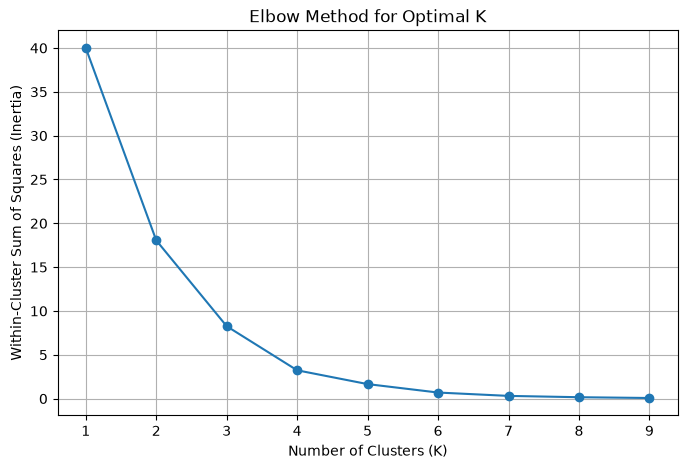

In [7]:
inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

    
plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.title("Elbow Method for Optimal K")

plt.grid(True)

plt.show()

In [8]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(scaled_features)

station_features["Cluster"] = cluster_labels

station_features.head()

C:\Users\Laptop Arena\anaconda3\envs\evresearch\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Station,Metric_Type,Peak,Valley,Peak_Valley_Difference,Average,Load_Factor,Cluster
0,A1,Power(kW),1688.9,0.0,1688.9,269.163615,0.159372,1
1,A2,Power(kW),3020.3,0.0,3020.3,674.418259,0.223295,2
2,A3,Power(kW),3418.8,0.0,3418.8,576.626919,0.168664,2
3,A4,Power(kW),8896.8,0.0,8896.8,1239.017558,0.139266,0
4,A5,Power(kW),61.6,0.0,61.6,8.028525,0.130333,1


In [9]:
cluster_distribution = (
    station_features["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_distribution

Cluster
0    1
1    6
2    2
3    1
Name: count, dtype: int64

In [10]:
cluster_characteristics = (
    station_features
    .groupby("Cluster")
    [
        [
            "Peak",
            "Valley",
            "Peak_Valley_Difference",
            "Average",
            "Load_Factor"
        ]
    ]
    .mean()
    .reset_index()
)

cluster_characteristics

,Cluster,Peak,Valley,Peak_Valley_Difference,Average,Load_Factor
0,0,8896.800000,0.0,8896.800000,1239.017558,0.139266
1,1,570.666667,0.0,570.666667,78.808909,0.125791
2,2,3219.550000,0.0,3219.550000,625.522589,0.195979
3,3,1099.200000,0.0,1099.200000,557.649174,0.507323


In [11]:
cluster_results_path = os.path.join(
    processed_path,
    "kmeans_cluster_results.csv"
)

station_features.to_csv(
    cluster_results_path,
    index=False
)

print("Cluster results saved")

Cluster results saved


In [12]:
cluster_characteristics_path = os.path.join(
    processed_path,
    "cluster_characteristics.csv"
)

cluster_characteristics.to_csv(
    cluster_characteristics_path,
    index=False
)

print("Cluster characteristics saved")

Cluster characteristics saved


In [13]:
cluster_characteristics = (
    station_features
    .groupby("Cluster")
    [
        [
            "Peak",
            "Valley",
            "Peak_Valley_Difference",
            "Average",
            "Load_Factor"
        ]
    ]
    .mean()
    .reset_index()
)

cluster_characteristics

,Cluster,Peak,Valley,Peak_Valley_Difference,Average,Load_Factor
0,0,8896.800000,0.0,8896.800000,1239.017558,0.139266
1,1,570.666667,0.0,570.666667,78.808909,0.125791
2,2,3219.550000,0.0,3219.550000,625.522589,0.195979
3,3,1099.200000,0.0,1099.200000,557.649174,0.507323


In [14]:
station_features.to_csv(
    os.path.join(processed_path, "kmeans_cluster_results.csv"),
    index=False
)

print("Cluster results saved")

Cluster results saved


In [15]:
cluster_characteristics.to_csv(
    os.path.join(processed_path, "cluster_characteristics.csv"),
    index=False
)

print("Cluster characteristics saved")

Cluster characteristics saved


In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_features)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = station_features["Cluster"]
pca_df["Station"] = station_features["Station"]

pca_df

,PC1,PC2,Cluster,Station
0,-0.268536,-0.154150,1,A1
1,0.968775,0.354648,2,A2
2,0.967450,-0.151922,2,A3
3,4.382790,-0.727464,0,A4
4,-1.402582,-0.300517,1,A5
5,-1.287623,0.554040,1,A6
6,-1.397463,-1.226458,1,A7
7,-1.470369,-0.658139,1,A8
8,0.117126,2.709070,3,A9
9,-0.609569,-0.399108,1,A10


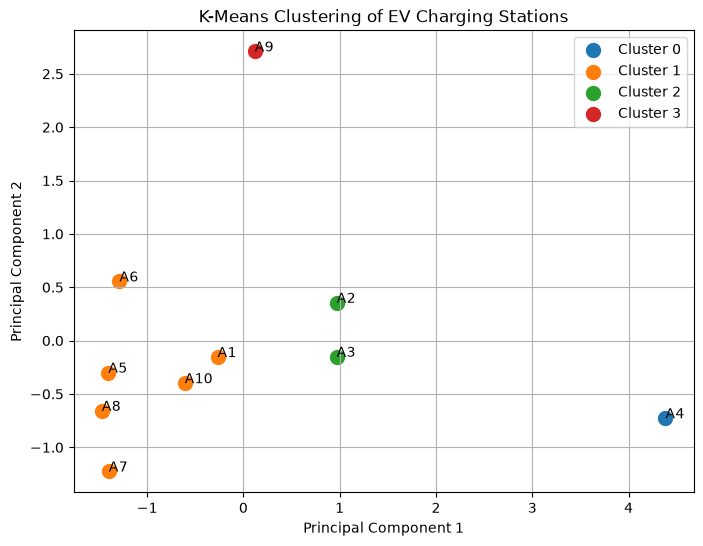

In [17]:
plt.figure(figsize=(8,6))

for cluster in sorted(pca_df["Cluster"].unique()):
    
    subset = pca_df[pca_df["Cluster"] == cluster]
    
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        s=100
    )

    for _, row in subset.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            row["Station"]
        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "K-Means Clustering of EV Charging Stations"
)

plt.legend()
plt.grid(True)

plt.show()

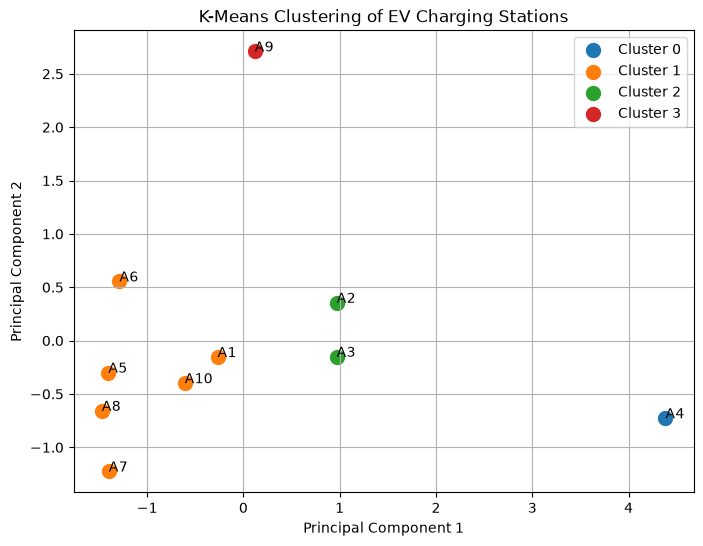

Cluster visualization saved


In [18]:
plt.figure(figsize=(8,6))

for cluster in sorted(pca_df["Cluster"].unique()):
    
    subset = pca_df[pca_df["Cluster"] == cluster]
    
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        s=100
    )

    for _, row in subset.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            row["Station"]
        )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("K-Means Clustering of EV Charging Stations")

plt.legend()
plt.grid(True)

plt.savefig(
    os.path.join(
        figure_path,
        "kmeans_cluster_visualization.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Cluster visualization saved")

In [19]:
cluster_distribution = (
    station_features["Cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_distribution.columns = [
    "Cluster",
    "Number_of_Stations"
]

cluster_distribution.to_csv(
    os.path.join(
        processed_path,
        "cluster_distribution.csv"
    ),
    index=False
)

print("Cluster distribution saved")

Cluster distribution saved
